🔍 Searching for available decades in /Users/neerajkaroshi/Desktop/Projects/clay_LULC/data/embeddings...
📅 Found years: ['1985', '1995', '2005']
🎯 Selected random spatial tile: cube_273.npz


/var/folders/nw/whndd4zx0yq8ggmr1g5hhd5m0000gn/T/ipykernel_68465/2006241575.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


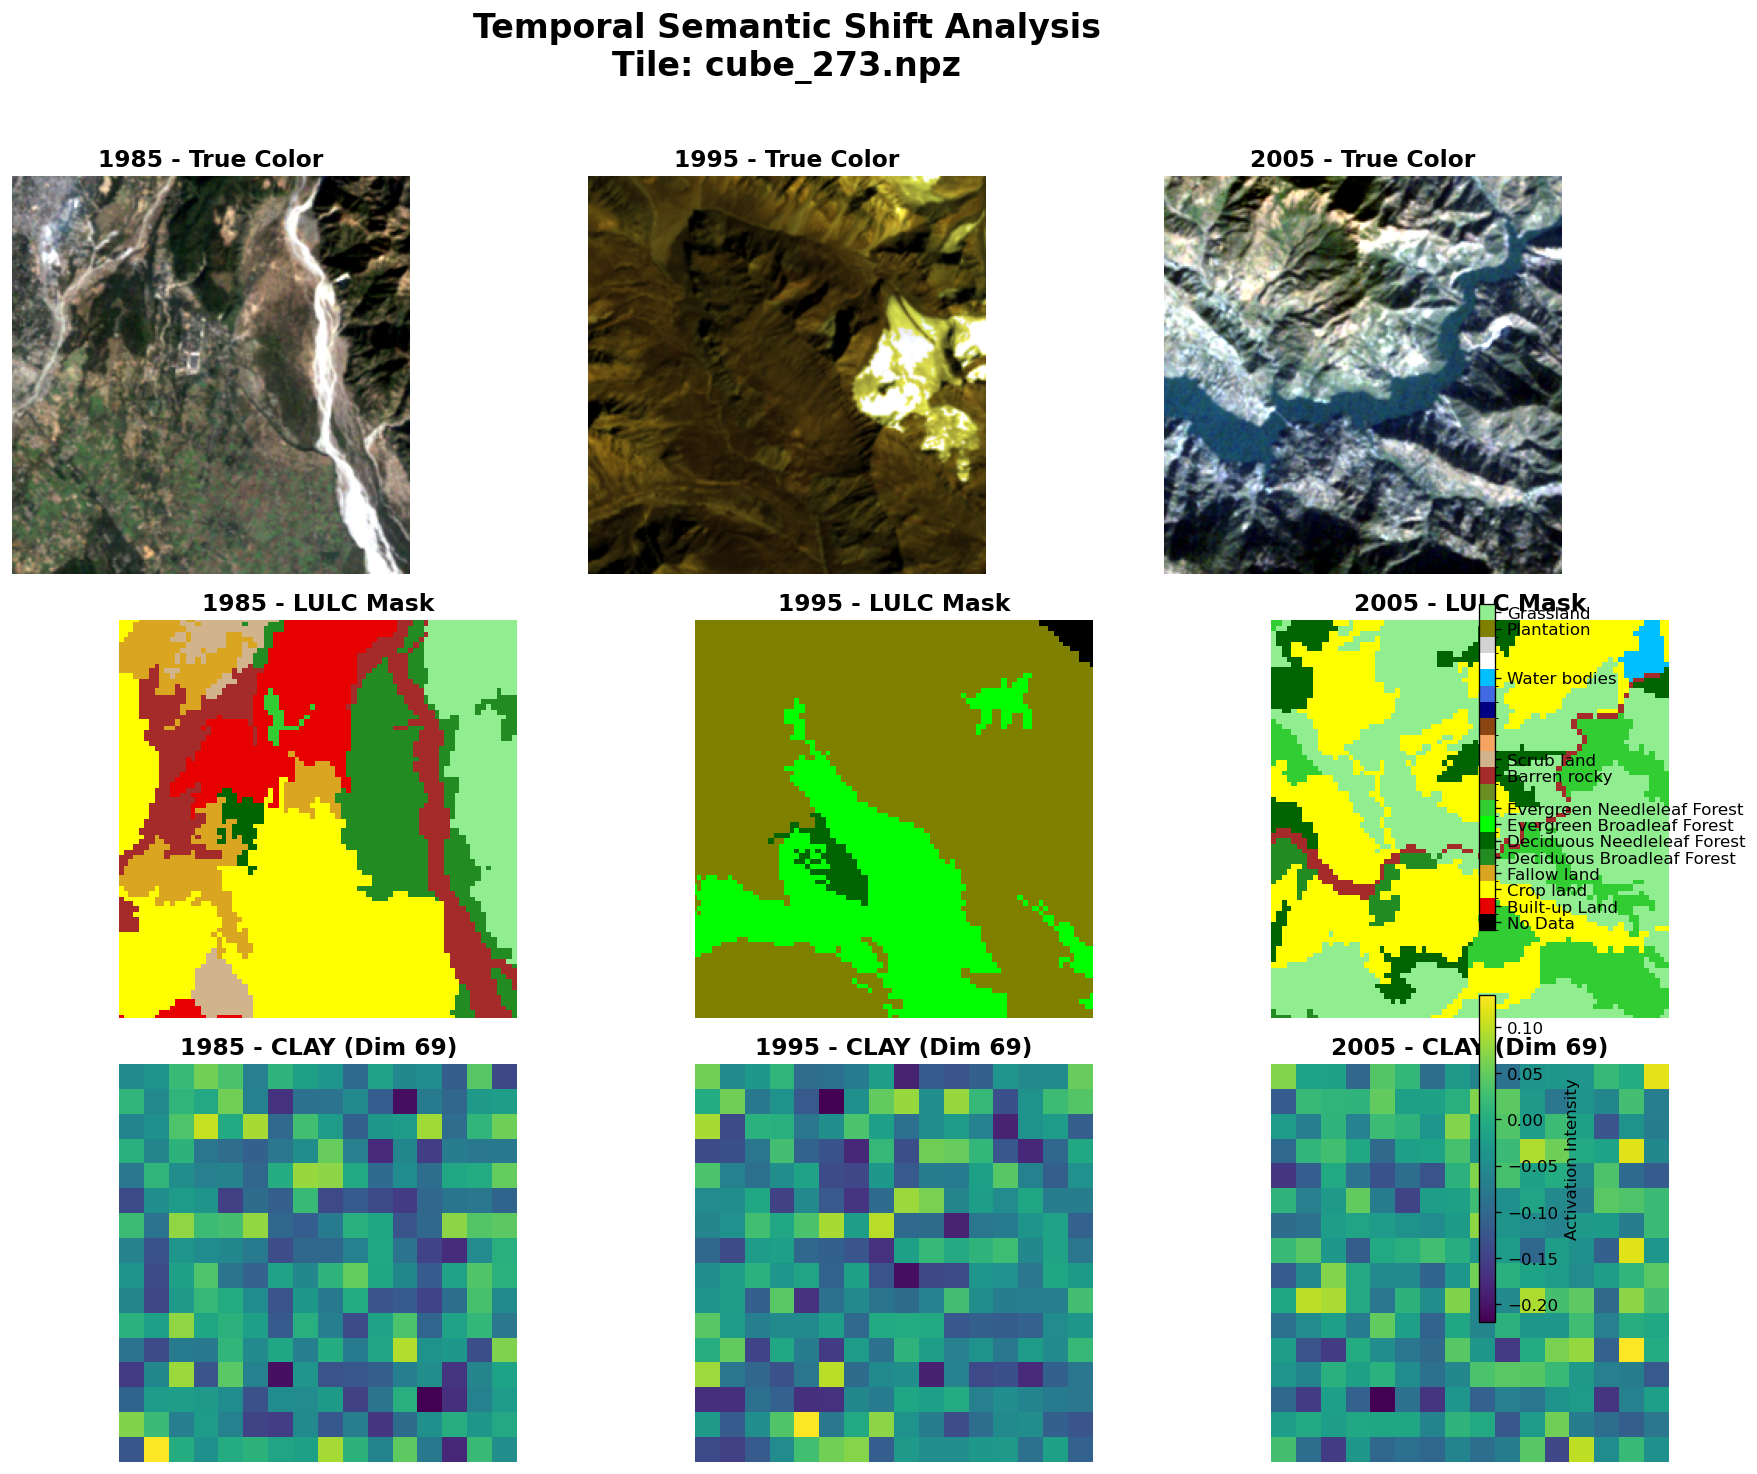

In [8]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
import random  # <-- ADDED for random tile selection

# ==========================================
# 1. FIX IMPORTS & PATHS
# ==========================================
# Add the parent 'src' directory to Python's path so it can find lulc_classes.py
sys.path.append('..')

# Import from lulc_classes (not lulc_legend)
try:
    from lulc_classes import LULC_CLASS_MAP, class_colors
except ImportError:
    print("❌ ERROR: Could not find 'lulc_classes.py'. Make sure your notebook is in src/Visualization/")
    sys.exit(1)

# Because the notebook is in `src/Visualization/`, we go up two levels (`../../`) to reach the root
DATA_DIR = Path('../../data/dataset/')
EMBED_DIR = Path('../../data/embeddings/')

# The specific embedding feature dimension to visualize (0 to 1023 or 767 depending on model)
EMBED_DIM = 69
# Updated grid dimensions to match the 16x16 patch layout
GRID_H, GRID_W = 16, 16

print(f"🔍 Searching for available decades in {EMBED_DIR.resolve()}...")
year_dirs = sorted([d for d in EMBED_DIR.iterdir() if d.is_dir()])
years = [d.name for d in year_dirs]
print(f"📅 Found years: {years}")

if not years:
    raise ValueError("No embedding directories found! Check your paths.")

# ==========================================
# 2. FIND A COMMON TILE ACROSS DECADES
# ==========================================
common_files = None
for y_dir in year_dirs:
    # Look for files that start with 'emb_cube_'
    files = set([f.name for f in y_dir.glob('emb_cube_*.npz')])
    if common_files is None:
        common_files = files
    else:
        common_files = common_files.intersection(files)

if not common_files:
    raise ValueError("Could not find a common cube_ID across all decades.")

# <-- CHANGED: Pick a random file instead of the first one
target_filename = random.choice(list(common_files))

# The original dataset cubes don't have the 'emb_' prefix
cube_filename = target_filename.replace('emb_', '')
print(f"🎯 Selected random spatial tile: {cube_filename}")

# ==========================================
# 3. VISUALIZATION UTILS
# ==========================================
def robust_stretch(img):
    """Enhances RGB imagery for plotting."""
    low, high = np.nanpercentile(img, (2, 98))
    return np.clip((img - low) / (high - low), 0, 1) if high > low else img

# Set up the exact color mapping from your imported config
cmap = ListedColormap(class_colors)
norm = BoundaryNorm(np.arange(-0.5, 20.5, 1), cmap.N)

# ==========================================
# 4. PLOT THE GRID
# ==========================================
fig, axes = plt.subplots(3, len(years), figsize=(5 * len(years), 12), dpi=120)

# Handle case where there's only 1 year to prevent indexing errors
if len(years) == 1:
    axes = np.expand_dims(axes, axis=1)

for col_idx, year in enumerate(years):
    # File Paths
    raw_path = DATA_DIR / year / cube_filename
    emb_path = EMBED_DIR / year / target_filename
    
    # Load Data
    with np.load(raw_path) as raw_data:
        # Dynamically check the keys so it doesn't crash
        if 'image' in raw_data:
            image = raw_data['image']
        elif 'pixels' in raw_data:
            image = raw_data['pixels']
        else:
            raise KeyError(f"Could not find 'image' or 'pixels' in {raw_path}. Available keys are: {raw_data.files}")
        
    with np.load(emb_path) as emb_data:
        if 'embedding' in emb_data:
            embeds = emb_data['embedding']
        elif 'embeddings' in emb_data:
            embeds = emb_data['embeddings']
        else:
            raise KeyError(f"Could not find 'embedding' in {emb_path}. Available keys: {emb_data.files}")
            
        mask = emb_data['mask']        
        
    # --- PROCESS RGB ---
    # Landsat order: [0:Red, 1:Green, 2:Blue] (Ensure these match your actual band indices)
    rgb_img = np.dstack([robust_stretch(image[i]) for i in [0, 1, 2]])
    
    # --- PROCESS EMBEDDING ---
    # 1. Strip off the [CLS] token (index 0) to get just the 256 spatial patches
    spatial_sequence = embeds[1:, :] # Shape becomes (256, 1024) or (256, 768)
    
    # 2. Reshape the 256 flat sequence into a 16x16 spatial grid
    spatial_embeds = spatial_sequence.reshape(GRID_H, GRID_W, -1)
    
    # 3. Extract the requested dimension
    single_dim_map = spatial_embeds[:, :, EMBED_DIM]
    
    # --- PLOTTING ---
    # Row 1: RGB
    ax_rgb = axes[0, col_idx]
    ax_rgb.imshow(rgb_img)
    ax_rgb.set_title(f"{year} - True Color", fontsize=14, fontweight='bold')
    ax_rgb.axis('off')
    
    # Row 2: Mask
    ax_mask = axes[1, col_idx]
    im_mask = ax_mask.imshow(mask, cmap=cmap, norm=norm, interpolation='nearest')
    ax_mask.set_title(f"{year} - LULC Mask", fontsize=14, fontweight='bold')
    ax_mask.axis('off')
    
    # Row 3: Embedding
    ax_emb = axes[2, col_idx]
    im_emb = ax_emb.imshow(single_dim_map, cmap='viridis') 
    ax_emb.set_title(f"{year} - CLAY (Dim {EMBED_DIM})", fontsize=14, fontweight='bold')
    ax_emb.axis('off')
    
    # Add an embedding colorbar to the last column only to keep it clean
    if col_idx == len(years) - 1:
        cbar_emb = plt.colorbar(im_emb, ax=axes[2, :], fraction=0.02, pad=0.04)
        cbar_emb.set_label("Activation Intensity")

# --- GLOBAL LULC LEGEND ---
# Extract unique classes present across ALL decades for this specific tile
all_masks = []
for year in years:
    with np.load(EMBED_DIR / year / target_filename) as d:
        all_masks.append(d['mask'])
present_ids = sorted(np.unique(np.concatenate(all_masks)))

# Filter out IDs that might not be in our map (safety check)
present_ids = [cid for cid in present_ids if cid in LULC_CLASS_MAP]

cbar_mask = plt.colorbar(im_mask, ax=axes[1, :], fraction=0.02, pad=0.04, ticks=present_ids)
cbar_mask.ax.set_yticklabels([LULC_CLASS_MAP[cid][1] for cid in present_ids])

plt.suptitle(f"Temporal Semantic Shift Analysis\nTile: {cube_filename}", fontsize=20, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

📅 Found years: ['1985', '1995', '2005']
🎯 Selected Tile: cube_313.npz


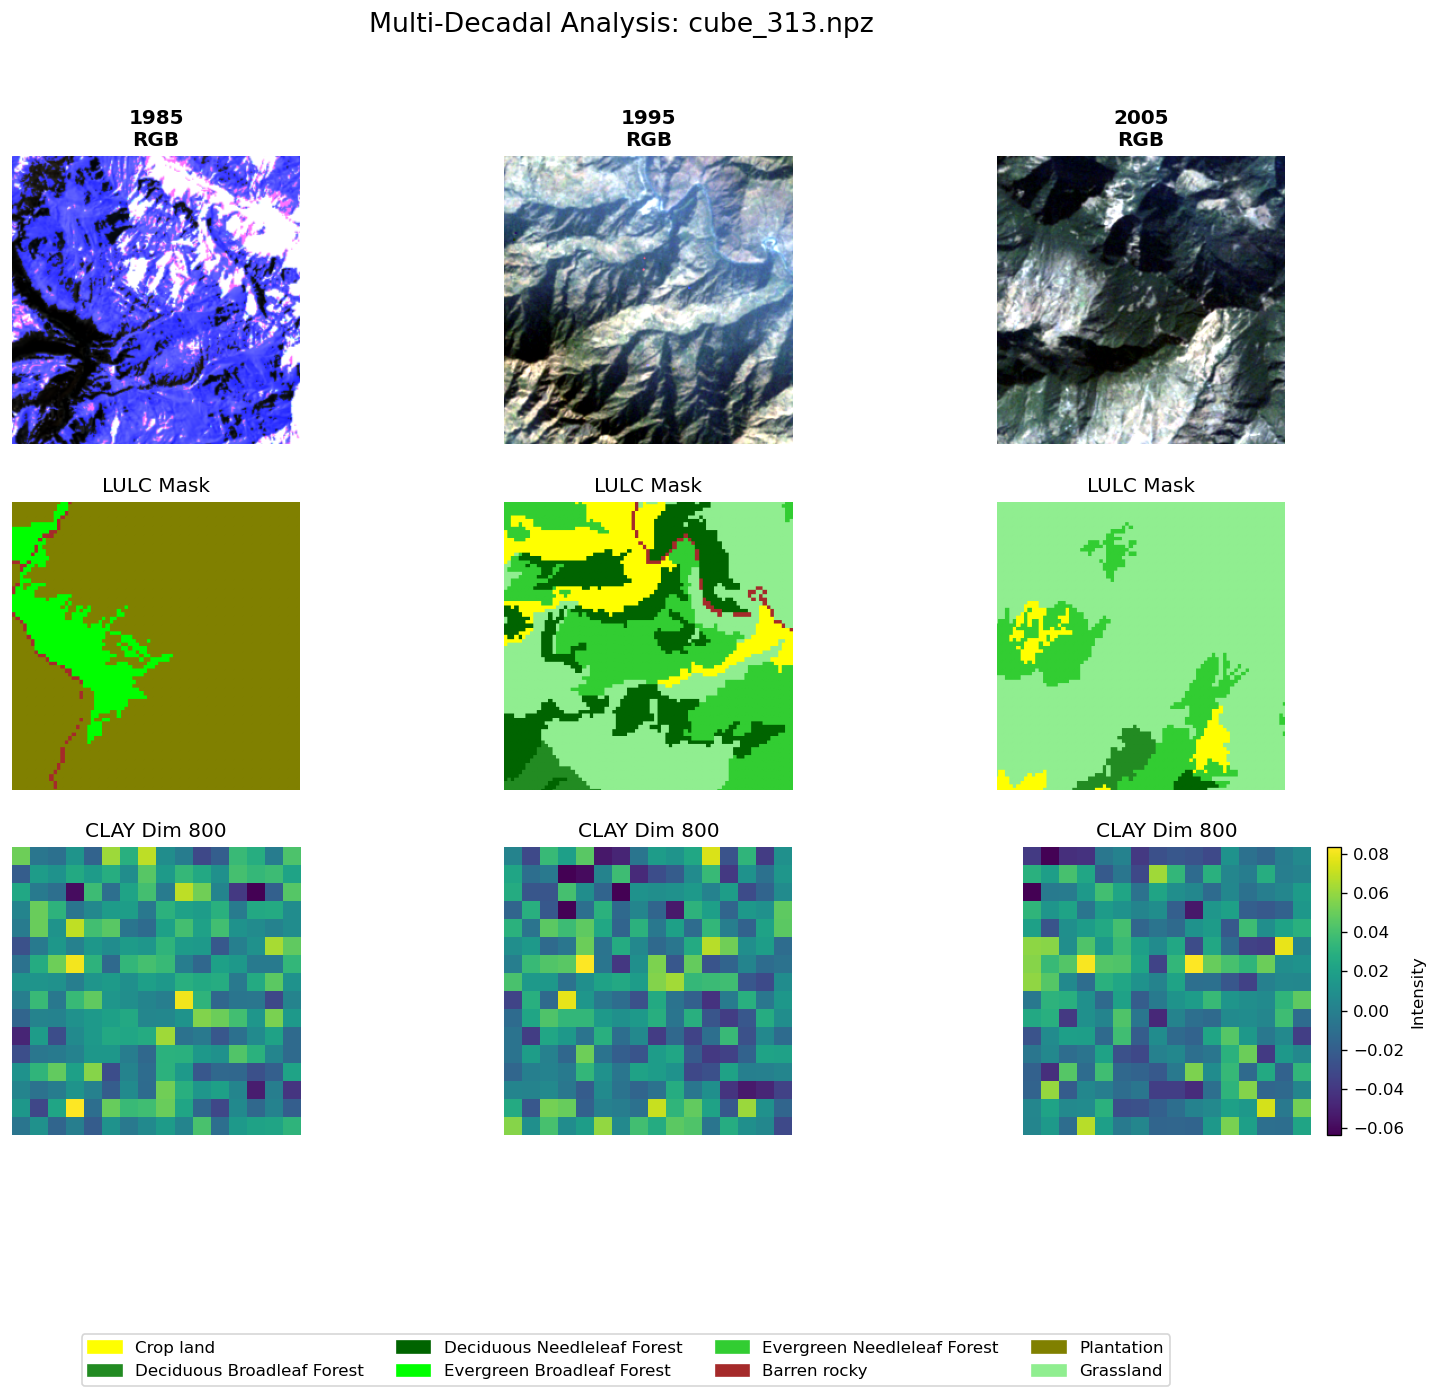

In [13]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
import random

# ==========================================
# 1. SETUP & PATHS
# ==========================================
sys.path.append('..')
try:
    from lulc_classes import LULC_CLASS_MAP, class_colors
except ImportError:
    print("❌ ERROR: Could not find 'lulc_classes.py'.")
    sys.exit(1)

DATA_DIR = Path('../../data/dataset/')
EMBED_DIR = Path('../../data/embeddings/')

EMBED_DIM = 800
GRID_H, GRID_W = 16, 16

years = sorted([d.name for d in EMBED_DIR.iterdir() if d.is_dir()])
print(f"📅 Found years: {years}")

# ==========================================
# 2. MATCH BY FILENAME (Spatially Consistent)
# ==========================================
# We find filenames that exist in EVERY decade folder
common_filenames = None
for year in years:
    files_in_year = set([f.name for f in (EMBED_DIR / year).glob('emb_cube_*.npz')])
    if common_filenames is None:
        common_filenames = files_in_year
    else:
        common_filenames = common_filenames.intersection(files_in_year)

if not common_filenames:
    print("❌ No common filenames found! Checking if coordinate matching is needed...")
    # If filenames are different, we'd need a different approach, 
    # but usually, dataset prep keeps filenames consistent.
    raise ValueError("Could not find any 'emb_cube_*.npz' files that exist in all year folders.")

# Pick a random tile from the intersection
target_filename = random.choice(list(common_filenames))
cube_filename = target_filename.replace('emb_', '')

print(f"🎯 Selected Tile: {cube_filename}")

# ==========================================
# 3. PLOT
# ==========================================
fig, axes = plt.subplots(3, len(years), figsize=(5 * len(years), 12), dpi=120)
plt.subplots_adjust(bottom=0.2) # Make room for legend

if len(years) == 1: axes = np.expand_dims(axes, axis=1)

captured_coords = ""

for col_idx, year in enumerate(years):
    raw_path = DATA_DIR / year / cube_filename
    emb_path = EMBED_DIR / year / target_filename
    
    # LOAD DATA
    with np.load(raw_path) as raw_data:
        image = raw_data['image'] if 'image' in raw_data else raw_data['pixels']
        
    with np.load(emb_path) as emb_data:
        embeds = emb_data['embedding'] if 'embedding' in emb_data else emb_data['embeddings']
        mask = emb_data['mask']
        # Try to get coords just for the title display
        if 'latlon' in emb_data: 
            c = emb_data['latlon']
            captured_coords = f"[{c[0]:.4f}, {c[1]:.4f}]"

    # PROCESS
    rgb_img = np.dstack([np.clip((image[i] - np.nanpercentile(image[i], 2)) / 
                                (np.nanpercentile(image[i], 98) - np.nanpercentile(image[i], 2)), 0, 1) 
                        for i in [0, 1, 2]])
    
    spatial_embeds = embeds[1:, :].reshape(GRID_H, GRID_W, -1)
    single_dim_map = spatial_embeds[:, :, EMBED_DIM]
    
    # DRAW
    axes[0, col_idx].imshow(rgb_img)
    axes[0, col_idx].set_title(f"{year}\nRGB", fontsize=12, fontweight='bold')
    
    axes[1, col_idx].imshow(mask, cmap=ListedColormap(class_colors), norm=BoundaryNorm(np.arange(-0.5, 20.5, 1), 20))
    axes[1, col_idx].set_title(f"LULC Mask", fontsize=12)
    
    im_emb = axes[2, col_idx].imshow(single_dim_map, cmap='viridis')
    axes[2, col_idx].set_title(f"CLAY Dim {EMBED_DIM}", fontsize=12)
    
    for r in range(3): axes[r, col_idx].axis('off')
    
    if col_idx == len(years) - 1:
        plt.colorbar(im_emb, ax=axes[2, col_idx], fraction=0.046, pad=0.04).set_label("Intensity")

# ==========================================
# 4. LEGEND (ONLY PRESENT CLASSES)
# ==========================================
all_mask_vals = []
for year in years:
    with np.load(EMBED_DIR / year / target_filename) as d:
        all_mask_vals.extend(np.unique(d['mask']))
present_ids = sorted(list(set(all_mask_vals)))
present_ids = [i for i in present_ids if i in LULC_CLASS_MAP]

legend_patches = [mpatches.Patch(color=class_colors[int(i)], label=LULC_CLASS_MAP[i][1]) for i in present_ids]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.02), fontsize=10)

plt.suptitle(f"Multi-Decadal Analysis: {cube_filename} {captured_coords}", fontsize=16, y=0.98)
plt.show()